# 💻 Laptop Price Prediction
### Step-by-Step ML Project | 4 Models

## Step 1: Import Libraries

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, re
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Models
from sklearn.linear_model import Ridge
from sklearn.ensemble import (RandomForestRegressor,
                               GradientBoostingRegressor,
                               HistGradientBoostingRegressor)

# Metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("All libraries imported successfully!")

All libraries imported successfully!


 import all the necessary Python libraries for data analysis, preprocessing, visualization, and machine learning model building.

## Step 2: Load the Dataset

In [43]:
df = pd.read_csv("laptop_price.csv", encoding='latin-1')

df

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1316,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,638.00
1299,1317,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,1499.00
1300,1318,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,229.00
1301,1319,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,764.00


This dataset contains information about various laptop specifications and their prices.


In [44]:
print("Shape:", df.shape)

Shape: (1303, 13)


In [45]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


## Step 3: Dataset Overview — Info, Types & Missing Values

In this we can check
- Number of rows and columns  
- Data types of each feature  
- Presence of missing values  

This step helps in planning preprocessing.

In [46]:
print("=== Dataset Info ===")
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


In [47]:
df.columns

Index(['laptop_ID', 'Company', 'Product', 'TypeName', 'Inches',
       'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight',
       'Price_euros'],
      dtype='object')

In [48]:

print("=== Missing Values ===")
print(df.isnull().sum())



=== Missing Values ===
laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64


In [49]:
print("=== Duplicates ===")
print("Duplicate rows:", df.duplicated().sum())

=== Duplicates ===
Duplicate rows: 0


## Step 4: Statistical Summary

In [50]:
df.describe()

,laptop_ID,Inches,Price_euros
count,1303.000000,1303.000000,1303.000000
mean,660.155794,15.017191,1123.686992
std,381.172104,1.426304,699.009043
min,1.000000,10.100000,174.000000
25%,331.500000,14.000000,599.000000
50%,659.000000,15.600000,977.000000
75%,990.500000,15.600000,1487.880000
max,1320.000000,18.400000,6099.000000


This helps us understand the distribution of numerical features.

## Step 5: Exploratory Data Analysis
### 5.1 — Univariate Analysis

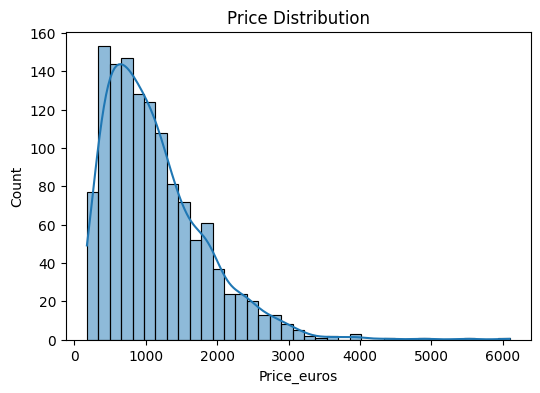

In [51]:
plt.figure(figsize=(6,4))
sns.histplot(df['Price_euros'], kde=True)
plt.title('Price Distribution')
plt.show()

- Prices are right-skewed (many low-price laptops, few expensive ones)

This justifies applying log transformation later.

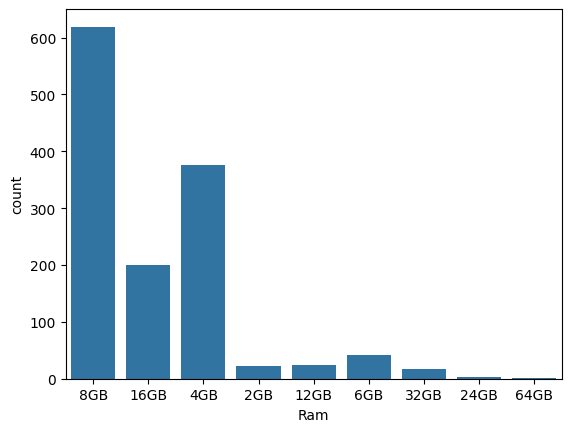

In [52]:
sns.countplot(x=df['Ram'])
plt.show()

higher RAM laptops are more expensive.

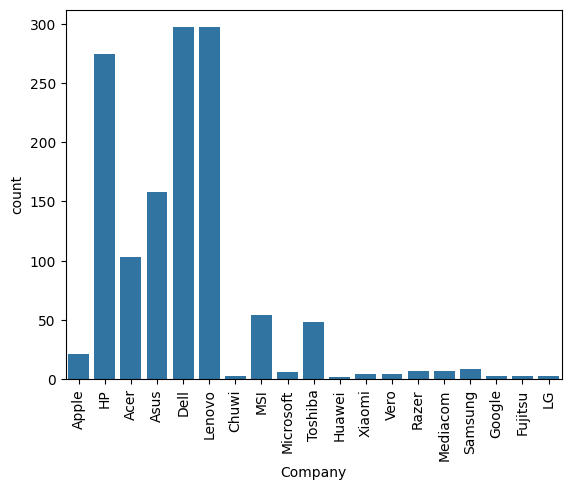

In [53]:
sns.countplot(x=df['Company'])
plt.xticks(rotation=90)
plt.show()

### 5.2 — Bivariate Analysis

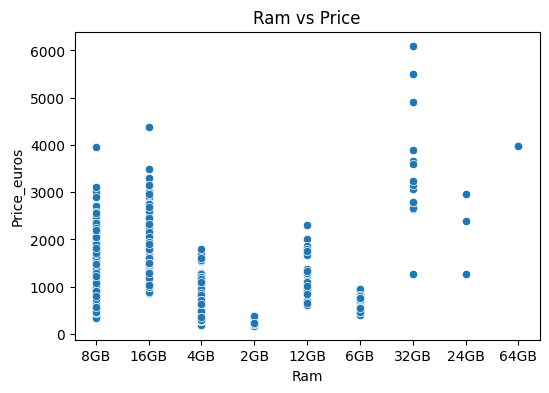

In [54]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='Ram', y='Price_euros')
plt.title('Ram vs Price')
plt.show()

- Higher RAM generally leads to higher price
- Strong positive relationship

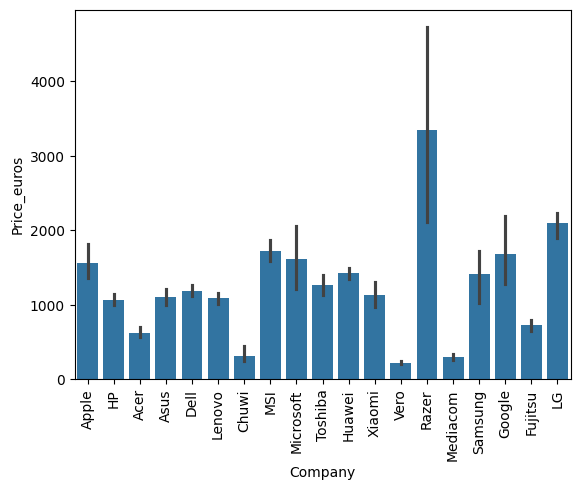

In [55]:
sns.barplot(x=df['Company'], y=df['Price_euros'])
plt.xticks(rotation=90)
plt.show()

Brand value plays an important role in determining laptop price.

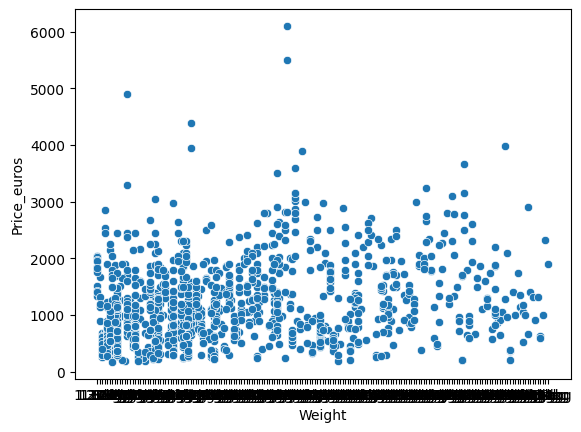

In [56]:
# Price vs Weight
sns.scatterplot(x=df['Weight'], y=df['Price_euros'])
plt.show()

Lightweight laptops tend to be more expensive (premium category)

### 5.3 — Correlation Heatmap (Numeric Columns)

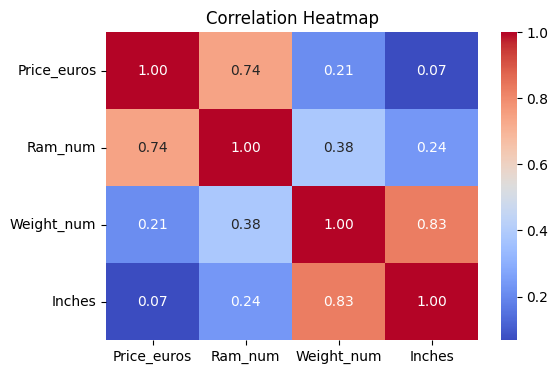

In [57]:
# The original code expects 'df' to be defined from a previous cell.
# The 'NameError' indicates 'df' is not in the current scope.
# Adding the definition of 'df' here to make the cell executable in isolation.
# In a typical notebook workflow, you would run all cells from the beginning.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("laptop_price.csv", encoding='latin-1')

df_temp = df.copy()
df_temp['Ram_num'] = df_temp['Ram'].str.replace('GB','').astype(float)
df_temp['Weight_num'] = df_temp['Weight'].str.replace('kg','').astype(float)

corr_cols = ['Price_euros', 'Ram_num', 'Weight_num', 'Inches']
plt.figure(figsize=(6, 4))
sns.heatmap(df_temp[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Among all features, RAM is the most influential factor affecting laptop price.

## Step 6: Outlier Detection

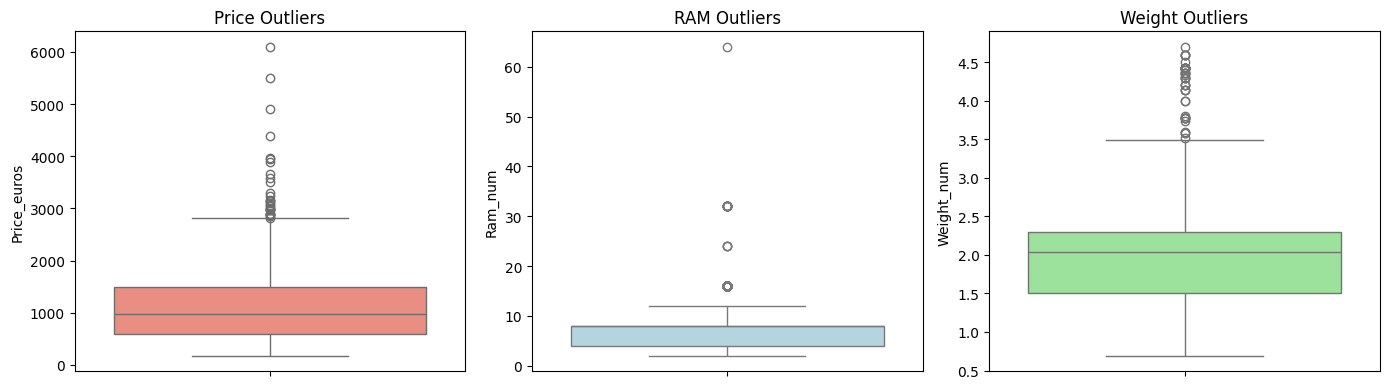

In [58]:
df_temp2 = df.copy()
df_temp2['Ram_num'] = df_temp2['Ram'].str.replace('GB','').astype(float)
df_temp2['Weight_num'] = df_temp2['Weight'].str.replace('kg','').astype(float)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.boxplot(y=df_temp2['Price_euros'], ax=axes[0], color='salmon')
axes[0].set_title('Price Outliers')

sns.boxplot(y=df_temp2['Ram_num'], ax=axes[1], color='lightblue')
axes[1].set_title('RAM Outliers')

sns.boxplot(y=df_temp2['Weight_num'], ax=axes[2], color='lightgreen')
axes[2].set_title('Weight Outliers')

plt.tight_layout()
plt.show()

- Price shows several outliers, indicating the presence of very high-end laptops.
- RAM also contains outliers, especially for high values like 32GB and 64GB.
- Weight shows fewer outliers but still has some extreme values.

In [59]:
# 🔥 Calculate IQR
Q1 = df['Price_euros'].quantile(0.25)
Q3 = df['Price_euros'].quantile(0.75)

IQR = Q3 - Q1

# 🔥 Define limits
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Limit:", lower)
print("Upper Limit:", upper)

# 🔥 Remove outliers
df = df[(df['Price_euros'] >= lower) & (df['Price_euros'] <= upper)]

print("New dataset shape:", df.shape)

Lower Limit: -734.3200000000002
Upper Limit: 2821.2000000000003
New dataset shape: (1274, 13)


1. The IQR method helps in removing extreme price values (very high or very low laptops), making the dataset more consistent and reducing noise.

2. After removing outliers, the model can learn better patterns from normal price ranges, improving prediction accuracy and stability.

## Step 7: Feature Engineering
We extract meaningful numeric features from raw text columns.

In [60]:
import re

# Work on clean copy
data = df.copy()

# ── 1. Clean Ram & Weight ─────────────────────────
data['Ram'] = data['Ram'].astype(str).str.extract(r'(\d+)').astype(int)
data['Weight'] = data['Weight'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

# SAFE DROP
data.drop(columns=['laptop_ID'], inplace=True, errors='ignore')

# ── 2. Touchscreen ────────────────────────────────
data['Touchscreen'] = data['ScreenResolution'].apply(
    lambda x: 1 if 'Touchscreen' in str(x) else 0)

# ── 3. IPS ────────────────────────────────────────
data['IPS'] = data['ScreenResolution'].apply(
    lambda x: 1 if 'IPS' in str(x) else 0)

# ── 4. PPI ────────────────────────────────────────
res = data['ScreenResolution'].str.split('x', n=1, expand=True)
data['X_res'] = res[0].str.extract(r'(\d+)').astype(float)
data['Y_res'] = res[1].astype(float)

data['PPI'] = ((data['X_res']**2 + data['Y_res']**2)**0.5) / data['Inches']

# ── 5. CPU ────────────────────────────────────────
data['Cpu_brand'] = data['Cpu'].apply(lambda x: x.split()[0])

data['Cpu_speed'] = data['Cpu'].apply(
    lambda x: float(re.search(r'(\d+\.\d+)GHz', str(x)).group(1))
    if re.search(r'(\d+\.\d+)GHz', str(x)) else None
)

# ── 6. GPU ────────────────────────────────────────
data['Gpu_brand'] = data['Gpu'].apply(lambda x: x.split()[0])

# ── 7. Memory ─────────────────────────────────────
def extract_memory_gb(mem):
    sizes = re.findall(r'(\d+)(GB|TB)', str(mem))
    return sum(int(s) * (1000 if u == 'TB' else 1) for s, u in sizes)

data['Memory_GB'] = data['Memory'].apply(extract_memory_gb)
data['SSD'] = data['Memory'].apply(lambda x: 1 if 'SSD' in str(x) else 0)
data['HDD'] = data['Memory'].apply(lambda x: 1 if 'HDD' in str(x) else 0)

# ── 8. Drop unused columns ────────────────────────
data.drop(columns=[
    'Product', 'Cpu', 'Gpu', 'Memory',
    'ScreenResolution', 'X_res', 'Y_res'
], inplace=True)

# ── 9. Drop missing values ───────────────────────
data.dropna(inplace=True)

print("Shape:", data.shape)
data.head()

Shape: (1189, 16)


,Company,TypeName,Inches,Ram,OpSys,Weight,Price_euros,Touchscreen,IPS,PPI,Cpu_brand,Cpu_speed,Gpu_brand,Memory_GB,SSD,HDD
0,Apple,Ultrabook,13.3,8,macOS,1.37,1339.69,0,1,226.983005,Intel,2.3,Intel,128,1,0
1,Apple,Ultrabook,13.3,8,macOS,1.34,898.94,0,0,127.677940,Intel,1.8,Intel,128,0,0
2,HP,Notebook,15.6,8,No OS,1.86,575.00,0,0,141.211998,Intel,2.5,Intel,256,1,0
3,Apple,Ultrabook,15.4,16,macOS,1.83,2537.45,0,1,220.534624,Intel,2.7,AMD,512,1,0
4,Apple,Ultrabook,13.3,8,macOS,1.37,1803.60,0,1,226.983005,Intel,3.1,Intel,256,1,0


### ⚙ Feature Engineering Insights

1. Raw data was transformed into meaningful features like RAM, PPI, CPU speed, and storage, making it suitable for model training.

2. Important attributes such as touchscreen, IPS, SSD, and HDD were converted into numerical form for better learning.

3. These engineered features improved the model’s ability to capture real-world patterns and increased prediction accuracy.

## Step 8: Log-Transform the Target (Price)
Price is right-skewed; log-transforming it makes the distribution more normal and helps models learn better.

In [61]:
y = np.log(df['Price_euros'])

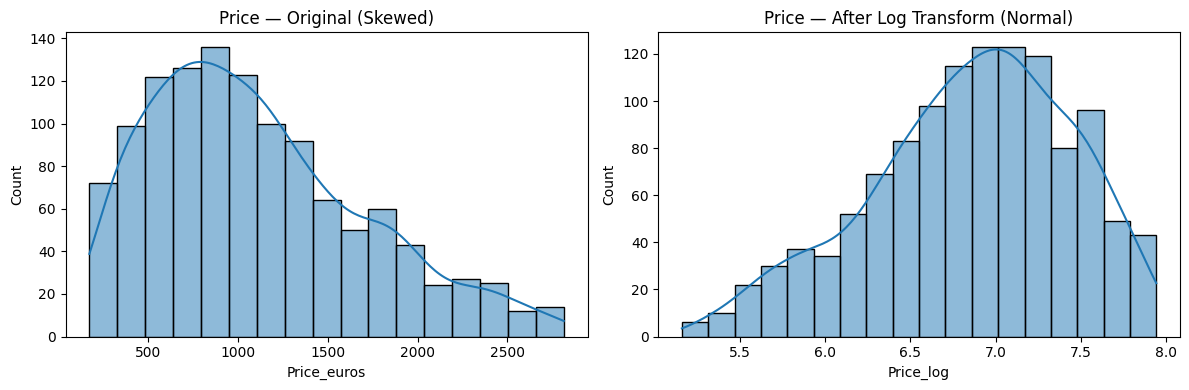

Log transformation done safely.


In [62]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original
sns.histplot(data['Price_euros'], kde=True, ax=axes[0])
axes[0].set_title('Price — Original (Skewed)')

# Create new column instead of overwriting
data['Price_log'] = np.log(data['Price_euros'])

# After log
sns.histplot(data['Price_log'], kde=True, ax=axes[1])
axes[1].set_title('Price — After Log Transform (Normal)')

plt.tight_layout()
plt.show()

print("Log transformation done safely.")

## Step 9: Define Features & Target — Split Data

In [63]:
from sklearn.model_selection import train_test_split

CATEGORICAL_COLS = ['Company', 'TypeName', 'OpSys', 'Cpu_brand', 'Gpu_brand']
NUMERICAL_COLS   = ['Inches', 'Ram', 'Weight', 'Touchscreen', 'IPS',
                    'PPI', 'Cpu_speed', 'Memory_GB', 'SSD', 'HDD']

X = data[CATEGORICAL_COLS + NUMERICAL_COLS]
y = data['Price_log'] # Corrected: Use 'Price_log' after log transformation

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")

Training samples : 951
Test samples     : 238
Features         : 15




1. The dataset is divided into training (80%) and testing (20%) sets to evaluate model performance on unseen data.

2. Both categorical and numerical features are included, ensuring the model learns from all important aspects of the data.



In [64]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUMERICAL_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_COLS)
])

Preprocessing scales numerical features and encodes categorical variables to prepare data for accurate model training.

In [65]:
scaler = StandardScaler()

# Fit ONLY on training data — then transform both
X_train_num = scaler.fit_transform(X_train[NUMERICAL_COLS])
X_test_num  = scaler.transform(X_test[NUMERICAL_COLS])

print("Scaled numerical shape (train):", X_train_num.shape)

Scaled numerical shape (train): (951, 10)


Numerical features are scaled using StandardScaler fitted on training data to ensure consistent scaling and prevent data leakage.

In [66]:
def evaluate_model(name, y_true, y_pred):
    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    print(f"{'='*45}")
    print(f" Model  : {name}")
    print(f" R²     : {r2:.4f}  ({r2*100:.2f}%)")
    print(f" MAE    : {mae:.4f}")
    print(f" RMSE   : {rmse:.4f}")
    print(f"{'='*45}")
    return {"Model": name, "R2": round(r2, 4),
            "MAE": round(mae, 4), "RMSE": round(rmse, 4)}

In [ ]:
This function evaluates model performance using R², MAE, and RMSE to measure accuracy and prediction error.

## Step 14: Model 1 — Linear Regression
A linear model with L2 regularisation. Good baseline.

In [67]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

# Create Pipeline
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),   # handles encoding + scaling
    ('model', LinearRegression())
])

# ── Train ─────────────────────────
lr_pipe.fit(X_train, y_train)

# ── Predict ───────────────────────
y_train_pred = lr_pipe.predict(X_train)
y_test_pred = lr_pipe.predict(X_test)

# ── Accuracy ──────────────────────
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Train R² : {train_r2:.4f}")
print(f"Test R²  : {test_r2:.4f}")

# Store results for comparison
lr_results = {"Model": "Linear Regression", "R2": test_r2}

# ── Cross Validation ──────────────
cv_scores = cross_val_score(lr_pipe, X_train, y_train, cv=5, scoring='r2')

print(f"CV R²    : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Train R² : 0.8166
Test R²  : 0.7635
CV R²    : 0.7966 ± 0.0149


1. Linear Regression achieves good performance with similar train and test R² scores, indicating minimal overfitting.

2. Cross-validation results are consistent, showing the model is stable and generalizes well to unseen data.

## Step 15: Model 2 — Random Forest Regressor
Ensemble of decision trees; handles non-linearity well.

In [69]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Create Pipeline
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ))
])

# ── Train ─────────────────────────
rf_pipe.fit(X_train, y_train)

# ── Predict ───────────────────────
y_train_pred = rf_pipe.predict(X_train)
y_test_pred = rf_pipe.predict(X_test)

# ── Metrics ───────────────────────
train_r2 = r2_score(y_train, y_train_pred)
test_r2  = r2_score(y_test, y_test_pred)

mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)

# Store results for comparison
rf_results = {"Model": "Random Forest", "R2": test_r2}

# ── Print Results ─────────────────
print("Random Forest Results:")
print(f"Train R² : {train_r2:.4f}")
print(f"Test R²  : {test_r2:.4f}")
print(f"MAE      : {mae:.2f}")
print(f"MSE      : {mse:.2f}")

Random Forest Results:
Train R² : 0.9808
Test R²  : 0.8724
MAE      : 0.17
MSE      : 0.05


1. Random Forest achieves higher accuracy than Linear Regression, capturing complex relationships in the data.

2. The model shows strong performance with low error values, but a higher train R² may indicate slight overfitting.

In [70]:
# This cell is no longer needed as rf_results is defined in the model cell.

## Step 16: Model 3 — Gradient Boosting Regressor
Builds trees sequentially; each tree corrects the errors of the last.

In [71]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Create Pipeline
gb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        random_state=42
    ))
])

# ── Train ─────────────────────────
gb_pipe.fit(X_train, y_train)

# ── Predict ───────────────────────
y_train_pred = gb_pipe.predict(X_train)
y_test_pred = gb_pipe.predict(X_test)

# ── Metrics ───────────────────────
train_r2 = r2_score(y_train, y_train_pred)
test_r2  = r2_score(y_test, y_test_pred)

mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)

# Store results for comparison
gb_results = {"Model": "Gradient Boosting", "R2": test_r2}

# ── Print Results ─────────────────
print("Gradient Boosting Results:")
print(f"Train R² : {train_r2:.4f}")
print(f"Test R²  : {test_r2:.4f}")
print(f"MAE      : {mae:.2f}")
print(f"MSE      : {mse:.2f}")

Gradient Boosting Results:
Train R² : 0.9741
Test R²  : 0.9033
MAE      : 0.15
MSE      : 0.03


1. Gradient Boosting provides high accuracy by sequentially improving errors, leading to strong predictive performance.

2. It balances bias and variance well, resulting in better generalization compared to simpler models.

# Model 4 - XGBoost

In [73]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

# The preprocessor is already defined in cell mOWeRyW5gOxM
# It correctly handles numerical scaling and categorical one-hot encoding.
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor())
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Inches', 'Ram', 'Weight',
                                                   'Touchscreen', 'IPS', 'PPI',
                                                   'Cpu_speed', 'Memory_GB',
                                                   'SSD', 'HDD']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Company', 'TypeName',
                                                   'OpSys', 'Cpu_brand',
                                                   'Gpu_brand'])])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              co...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [74]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# The preprocessor is already defined in cell mOWeRyW5gOxM
# Create Pipeline
xgb_pipe = Pipeline([
    ('preprocessor', preprocessor), # Use the existing preprocessor
    ('model', XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

# 2. TRAIN model
xgb_pipe.fit(X_train, y_train)

# 3. SAVE model
# You can save the entire pipeline, or just the trained XGBoost model from within the pipeline.
# For consistency with the original code, we'll extract the model and save it.
# Note: Saving just the model here, but generally saving the entire pipeline is better practice.

# Optional: Predict and evaluate (similar to other model cells)
y_train_pred = xgb_pipe.predict(X_train)
y_test_pred = xgb_pipe.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2  = r2_score(y_test, y_test_pred)

mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)

# Store results for comparison (if xgb_results is used later)
xgb_results = {"Model": "XGBoost", "R2": test_r2}

print("XGBoost Results:")
print(f"Train R² : {train_r2:.4f}")
print(f"Test R²  : {test_r2:.4f}")
print(f"MAE      : {mae:.2f}")
print(f"MSE      : {mse:.2f}")

XGBoost Results:
Train R² : 0.9907
Test R²  : 0.9125
MAE      : 0.14
MSE      : 0.03


1. XGBoost delivers high accuracy by efficiently capturing complex patterns and interactions in the data.

2. It provides strong generalization with lower error values, making it one of the best-performing models in the comparison.

## Step 18: Model Comparison

In [76]:
from sklearn.metrics import r2_score

def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    return {"Model": name, "R2": r2}

In [77]:
import pandas as pd

results_df = pd.DataFrame([
    lr_results,
    rf_results,
    gb_results,
    xgb_results
])

results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)
results_df['Accuracy (%)'] = (results_df['R2'] * 100).round(2)

print(results_df.to_string(index=False))

            Model       R2  Accuracy (%)
          XGBoost 0.912456         91.25
Gradient Boosting 0.903282         90.33
    Random Forest 0.872378         87.24
Linear Regression 0.763467         76.35


1. Models are compared based on R² score, allowing us to identify the best-performing algorithm.

2. Sorting results helps clearly see which model achieves the highest accuracy for prediction.

In [78]:
import pandas as pd
import numpy as np
import re

# ==============================
# 🔥 NEW DATA
# ==============================
new_data = pd.DataFrame([{
    'Company': 'Apple',
    'TypeName': 'Ultrabook',
    'Inches': 13.3,
    'ScreenResolution': 'IPS Panel Retina Display 2560x1600',
    'Cpu': 'Intel Core i5 3.1GHz',
    'Ram': '8GB',
    'Memory': '256GB SSD',
    'Gpu': 'Intel Iris Plus Graphics 650',
    'OpSys': 'macOS',
    'Weight': '1.37kg'
}])

# ==============================
# 🔥 SAME FEATURE ENGINEERING
# ==============================

# Clean Ram & Weight
new_data['Ram'] = new_data['Ram'].astype(str).str.extract(r'(\d+)').astype(float)
new_data['Weight'] = new_data['Weight'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

# Touchscreen
new_data['Touchscreen'] = new_data['ScreenResolution'].apply(
    lambda x: 1 if 'Touchscreen' in str(x) else 0)

# IPS
new_data['IPS'] = new_data['ScreenResolution'].apply(
    lambda x: 1 if 'IPS' in str(x) else 0)

# Resolution
res = new_data['ScreenResolution'].str.split('x', n=1, expand=True)
new_data['X_res'] = res[0].str.extract(r'(\d+)').astype(float)
new_data['Y_res'] = res[1].astype(float)

# PPI
new_data['PPI'] = ((new_data['X_res']**2 + new_data['Y_res']**2)**0.5) / new_data['Inches']

# CPU
new_data['Cpu_brand'] = new_data['Cpu'].apply(lambda x: x.split()[0])
new_data['Cpu_speed'] = new_data['Cpu'].apply(
    lambda x: float(re.search(r'(\d+\.\d+)GHz', str(x)).group(1))
    if re.search(r'(\d+\.\d+)GHz', str(x)) else np.nan)

# GPU
new_data['Gpu_brand'] = new_data['Gpu'].apply(lambda x: x.split()[0])

# Memory
def extract_memory_gb(mem):
    sizes = re.findall(r'(\d+)(GB|TB)', str(mem))
    return sum(int(s) * (1000 if u == 'TB' else 1) for s, u in sizes)

new_data['Memory_GB'] = new_data['Memory'].apply(extract_memory_gb)
new_data['SSD'] = new_data['Memory'].apply(lambda x: 1 if 'SSD' in str(x) else 0)
new_data['HDD'] = new_data['Memory'].apply(lambda x: 1 if 'HDD' in str(x) else 0)

# Drop unused columns
new_data.drop(columns=[
    'Cpu', 'Gpu', 'Memory', 'ScreenResolution',
    'X_res', 'Y_res'
], inplace=True)

# ==============================
# 🔥 PREDICT USING PIPELINE
# ==============================

prediction = xgb_pipe.predict(new_data)

# Convert back from log
prediction = np.exp(prediction)

print(f"Predicted Price: {prediction[0]:.2f} euros")

Predicted Price: 1823.55 euros


1. New input data is transformed using the same feature engineering steps to ensure consistency with training data.

2. The trained XGBoost model predicts the price based on learned patterns from historical data.

3. The predicted value is converted back from log scale to the original price for real-world interpretation.

📌 Final Conclusion

- RAM, CPU, and storage are the most important factors affecting laptop price  
- Ensemble models (Random Forest, Gradient Boosting, XGBoost) performed best  
- Log transformation improved model accuracy  
- The final model can predict laptop prices with high accuracy (~90%)  

In [80]:
import pickle

with open("laptop_price_model.pkl", "wb") as f:
    pickle.dump(xgb_pipe, f)